<a href="https://colab.research.google.com/github/kumarsusheel7497-collab/Customer-Churn-Analysis/blob/main/Customer_Churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving customers.csv to customers.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("customers.csv")
df.head()

,id,name,segment,state,city
0,CG-12520,Claire Gute,Consumer,Kentucky,Henderson
1,DV-13045,Darrin Van Huff,Corporate,California,Los Angeles
2,SO-20335,Sean O'Donnell,Consumer,Florida,Fort Lauderdale
3,BH-11710,Brosina Hoffman,Consumer,California,Los Angeles
4,AA-10480,Andrew Allen,Consumer,North Carolina,Concord


In [5]:
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Shape of dataset: (793, 5)

First 5 rows:
         id             name    segment           state             city
0  CG-12520      Claire Gute   Consumer        Kentucky        Henderson
1  DV-13045  Darrin Van Huff  Corporate      California      Los Angeles
2  SO-20335   Sean O'Donnell   Consumer         Florida  Fort Lauderdale
3  BH-11710  Brosina Hoffman   Consumer      California      Los Angeles
4  AA-10480     Andrew Allen   Consumer  North Carolina          Concord

Column names:
Index(['id', 'name', 'segment', 'state', 'city'], dtype='object')

Data types:
id         object
name       object
segment    object
state      object
city       object
dtype: object

Missing values:
id         0
name       0
segment    0
state      0
city       0
dtype: int64

Duplicate rows: 0


In [6]:
df = df.drop_duplicates()
print("Duplicate rows removed successfully.")
print("New shape:", df.shape)

Duplicate rows removed successfully.
New shape: (793, 5)


In [7]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print(df.columns)

Index(['id', 'name', 'segment', 'state', 'city'], dtype='object')


In [9]:
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].replace(" ", np.nan)
    df[col] = df[col].fillna("Unknown")

In [10]:
if 'totalcharges' in df.columns:
    df['totalcharges'] = pd.to_numeric(df['totalcharges'], errors='coerce')
    df['totalcharges'] = df['totalcharges'].fillna(df['totalcharges'].median())

In [11]:
if 'churn' in df.columns:
    df['churn'] = df['churn'].astype(str).str.strip().str.title()

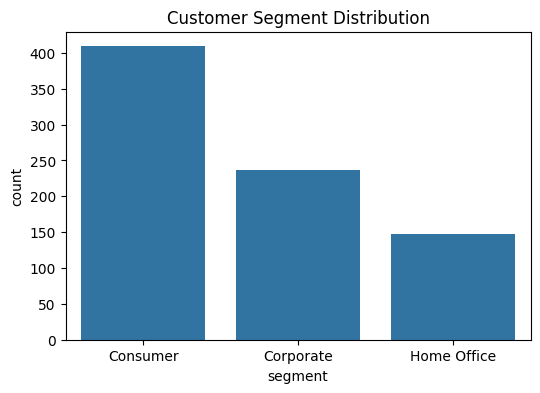

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x='segment', data=df)
plt.title("Customer Segment Distribution")
plt.show()

In [14]:
if 'gender' in df.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x='gender', hue='churn', data=df)
    plt.title("Churn by Gender")
    plt.show()

In [15]:
if 'contract' in df.columns:
    plt.figure(figsize=(8,4))
    sns.countplot(x='contract', hue='churn', data=df)
    plt.title("Churn by Contract Type")
    plt.xticks(rotation=20)
    plt.show()

In [16]:
if 'paymentmethod' in df.columns:
    plt.figure(figsize=(10,5))
    sns.countplot(x='paymentmethod', hue='churn', data=df)
    plt.title("Churn by Payment Method")
    plt.xticks(rotation=45)
    plt.show()

In [17]:
if 'monthlycharges' in df.columns:
    plt.figure(figsize=(7,4))
    sns.histplot(df['monthlycharges'], kde=True)
    plt.title("Monthly Charges Distribution")
    plt.show()

In [18]:
if 'tenure' in df.columns:
    plt.figure(figsize=(7,4))
    sns.histplot(df['tenure'], kde=True)
    plt.title("Customer Tenure Distribution")
    plt.show()

In [19]:
if 'churn' in df.columns:
    print(df['churn'].value_counts())
    print("\nChurn Percentage:")
    print(df['churn'].value_counts(normalize=True) * 100)

In [20]:
df.to_csv("cleaned_customer.csv", index=False)
print("Cleaned churn dataset saved successfully.")

Cleaned churn dataset saved successfully.


In [22]:
from google.colab import files
files.download("cleaned_customer.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>